#Обзор практической части: реализация функций и анализ результатов на синтетических данных.


Импортируем нужные библиотеки.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.isotonic import isotonic_regression
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import roc_auc_score

%matplotlib inline

Зафиксируем состояние для воспроизводимости.

In [ ]:
import random
import os

def seed_everything(seed=0):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)

seed_everything(30)

##Генерация синтетических данных.

Функция реализует генерацию синтетических данных для тестирования Uplift-модели в соответствии с описаной теорий. Основная цель этого этапа заключается в создании среды, где для каждого объекта заранее известны все потенциальные исходы, что позволяет оценить точность работы алгоритмов(в отличие от реальных данных, где такой возможности нет).

Вектор признаков `X`  моделирует признаки клиента: информативные (отвечают за базовую конверсию), признаки аплифта (определяют чувствительность к воздействию), смешанные и шумовые компоненты. Параметр `T` отражает уровень примененного маркетингового стимула, начиная от полного отсутствия контакта в контрольной группе.

Переменная `mu_true`, представляющая собой вектор истинных вероятностей совершения покупки для каждого возможного сценария(в реальности мы не знаем этих параметров, но здесь можем проверить на них правильность наших предсказаний). Расчет этих значений производится таким образом, чтобы строго соблюдалась гипотеза монотонности: вероятность отклика не может снижаться при увеличении интенсивности воздействия. Конечный наблюдаемый результат `Y_observed` формируется как бинарная величина на основе `mu_true` и фактически назначенного тритмента `T`. Подход позволяет в дальнейшем сопоставить эмпирические оценки модели с истинными значениями и подтвердить эффективность восстановления структуры данных с помощью PAVA-регуляризации.

In [ ]:
def generate_ordinal_uplift_data(n_samples, n_treatments=3):
    #информативные признаки 5 штук, для определения базовой вероятности покупки
    #без какого-либо воздействия
    X_info, y_base = make_classification(
        n_samples=n_samples, n_features=5, n_informative=5, n_redundant=0,
        random_state=42, weights=[0.7, 0.3]
    )
    #реакция на рекламу 3 признака
    X_uplift = np.random.normal(0, 1, size=(n_samples, 3))
    #шум
    X_irrelevant = np.random.normal(0, 1, size=(n_samples, 2))
    #линейная комбинация первых двух
    X_mix = 0.5 * X_info[:, :2] + 0.5 * X_uplift[:, :2]
    X = np.hstack((X_info, X_uplift, X_mix, X_irrelevant))

    #случайное назначение воздействия
    T = np.random.randint(0, n_treatments + 1, size=n_samples)

    mu_true = np.zeros((n_samples, n_treatments + 1))
    mu_true[:, 0] = y_base #реакция до применения скидки

    #монотонное увеличение вероятности при росте уровня воздействия
    for k in range(1, n_treatments + 1):
        uplift_effect = 1 / (1 + np.exp(-X_uplift[:, 0] * k))
        uplift_effect = uplift_effect * 0.15 #инкремент
        mu_true[:, k] = np.minimum(mu_true[:, k-1] + uplift_effect, 1.0)

    #наблюдаемый отклик Y Бернулли
    Y_observed = np.zeros(n_samples)
    for i in range(n_samples):
        Y_observed[i] = np.random.binomial(1, mu_true[i, T[i]])

    return X, T, Y_observed, mu_true

Класс `OrdinalUpliftModel` реализует архитектуру T-learner с изотонной(синоним с изотонической) регрессией для логической непротиворечивости предсказаний. При инициализации создается массив классификаторов `RandomForestClassifier` для оценки вероятности отклика на каждом уровне воздействия.

Метод `fit` обучает модели на подвыборках данных, соответствующих уровню воздействия. Это позволяет изолированно оценивать реакцию сегментов аудитории на интенсивность стимула.

Метод `predict_mu` состоит из двух этапов. На первом формируется матрица оценок `mu_raw`, содержащая аномалии из-за шума и нарушения условия монотонности. На втором алгоритм PAVA выполняет метрическую проекцию вектора вероятностей на конус монотонных последовательностей.

Гарантируется выполнение гипотезы монотонности: вероятность отклика не убывает при росте интенсивности воздействия. Скорректированные оценки `mu_pava` используются для оптимизации Net Value и выбора экономически эффективного уровня воздействия для каждого индивида.

In [ ]:
class OrdinalUpliftModel:
    def __init__(self, n_treatments):
        self.n_treatments = n_treatments
        self.models = [RandomForestClassifier(max_depth=5, random_state=42) for _ in range(n_treatments + 1)]

    def fit(self, X, T, y):
        for k in range(self.n_treatments + 1):
            mask = (T == k)
            if np.sum(mask) > 0:
                self.models[k].fit(X[mask], y[mask])

    def predict_mu(self, X):
        mu_raw = np.zeros((X.shape[0], self.n_treatments + 1))
        for k in range(self.n_treatments + 1):
            mu_raw[:, k] = self.models[k].predict_proba(X)[:, 1]

        #PAVA-фильтр для обеспечения монотонности mu_0 <= mu_1 <= ... <= mu_K
        mu_pava = np.zeros_like(mu_raw)
        for i in range(X.shape[0]):
            mu_pava[i, :] = isotonic_regression(mu_raw[i, :])
        return mu_raw, mu_pava

Класс `UpliftEvaluator` предназначен для оценки качества моделей и их эффективности в соответствии с метриками, описанными в главах 2 и 3 исследования.

Метод `calculate_nv` реализует расчет ожидаемой чистой ценности (Expected Net Value) для каждого уровня воздействия. Математическая логика учитывает бизнес ценность успешной конверсии, условные затраты на примененные скидки и фиксированные издержки на коммуникацию, что позволяет перейти от ранжирования к выбору оптимальной стратегии назначения тритмента.

Метод `get_procini_stats` выполняет статистический вывод на основе метрики PROCiniS. В основе кода лежит интерпретация площади под кривой как вероятности правильного ранжирования хороших и плохих целей. Для оценки статистической значимости превосходства моделей используется формула Ван Данцига, позволяющая рассчитать дисперсию и построить доверительные интервалы с учетом зависимостей при ранжировании.

Метод `get_sensitivity_by_band` реализует подход оценки на реальных данных через измерения чувствительности (elasticity). Алгоритм выполняет квантильное разбиение группы по предсказанному аплифту и оценивает коэффициент отклика $\beta_1$ с помощью линейной регрессии для каждой группы. Это позволяет визуализировать распределение эффекта и подтвердить способность модели выделять наиболее восприимчивые сегменты аудитории.

In [ ]:
class UpliftEvaluator:
    def __init__(self, n_treatments):
        self.n_treatments = n_treatments

    def calculate_nv(self, mu_preds, v, s_costs, c_costs):
        """Расчет Net Value для каждого уровня воздействия (раздел 3.2)"""
        NV = np.zeros_like(mu_preds)
        for k in range(self.n_treatments + 1):
            NV[:, k] = (v - s_costs[k]) * mu_preds[:, k] - c_costs[k]
        return NV

    def get_procini_stats(self, y_true, t_true, uplift_pred, k, alpha=0.05):
        """PROCiniS и доверительные интервалы Ван Данцига (раздел 2.3.4)"""
        mask = (t_true == 0) | (t_true == k)
        y_f, u_f = y_true[mask], uplift_pred[mask]

        #PROCiniS эквивалентен AUC при бинарном отклике
        A = roc_auc_score(y_f, u_f)
        NX, NY = np.sum(y_f == 1), np.sum(y_f == 0)

        #формула Ван Данцига
        Q1, Q2 = A / (2 - A), (2 * A**2) / (1 + A)
        var_A = (A*(1-A) + (NX-1)*(Q1-A**2) + (NY-1)*(Q2-A**2)) / (NX * NY)
        se_A = np.sqrt(var_A)

        z = stats.norm.ppf(1 - alpha/2)
        return A, (A - z*se_A, A + z*se_A)

    def get_sensitivity_by_band(self, y_true, t_true, uplift_pred, n_bins=10):
        """Эмпирическая чувствительность по бинам (раздел 2.3.5)"""
        df = pd.DataFrame({'y': y_true, 't': t_true, 'u': uplift_pred})
        df = df.sort_values('u', ascending=False).reset_index(drop=True)
        df['bin'] = pd.qcut(df.index, q=n_bins, labels=False)

        results = []
        for b in range(n_bins):
            grp = df[df['bin'] == b]
            # регрессия y = beta_0 + beta_1 * t + e
            reg = LinearRegression().fit(grp[['t']], grp['y'])
            results.append({'bin': b+1, 'sensitivity': reg.coef_[0]})
        return pd.DataFrame(results)

Функция реализует расчет компонента усталости (fatigue), описанного в разделе 3.3 исследования. Она определяет величину снижения базовой вероятности конверсии в будущем периоде в зависимости от интенсивности текущего воздействия $k$. Линейная аппроксимация с коэффициентом 0.02 позволяет модели учитывать долгосрочный штраф за агрессивный маркетинг, предотвращая стратегию выжженной земли.

In [ ]:
def decay_function(k):
    return k * 0.02

Реализованная функция `calculate_long_term_nv` производит вычисление совокупного вознаграждения $NV_{total}$ как суммы немедленной прибыли и дисконтированного будущего дохода.

Просходит учет функции усталости $\delta(k_1)$, которая моделирует снижение вероятности конверсии $\mu_0$ вследствие воздействия в текущем периоде. Введение коэффициента дисконтирования $\gamma$ позволяет сбалансировать значимость будущих доходов относительно текущих. Подход предохраняет алгоритм от выбора агрессивных краткосрочных стратегий, ведущих к снижении лояльности клиента.

In [ ]:
def calculate_long_term_nv(mu_pava, v, s_costs, c_costs, gamma):
    """
    Расчет совокупной прибыли за два периода (раздел 3.3).
    Реализует баланс между мгновенным доходом и будущей лояльностью клиента.
    """
    n_samples, n_treats = mu_pava.shape
    NV_total = np.zeros_like(mu_pava)
    for k1 in range(n_treats):
        #мгновенная чистая ценность - доход от конверсии минус затраты на акцию
        immediate_nv = (v - s_costs[k1]) * mu_pava[:, k1] - c_costs[k1]
        #прогноз конверсии - базовая вероятность за вычетом эффекта усталости
        future_base_conversion = np.maximum(mu_pava[:, 0] - decay_function(k1), 0)
        #будущая чистая ценность - доход во втором периоде без новых затрат
        future_nv = v * future_base_conversion - c_costs[0]
        #итоговая оценка - сумма текущей прибыли и дисконтированного будущего дохода
        NV_total[:, k1] = immediate_nv + gamma * future_nv
    return NV_total

Блок ниже реализует основной цикл эксперимента: генерация данных, обучение модели, выполняется расчет ожидаемой чистой ценности (Net Value) и проверка соблюдения гипотезы монотонности для стандартного и модифицированного PAVA-метода, оценка эффективности стратегий на тестовой выборке.

In [ ]:
#настройки
K = 3
v = 1000
s_costs = [0, 50, 100, 150]
c_costs = [0, 10, 20, 30]

#генерация и разделение данных
X, T, Y, mu_true = generate_ordinal_uplift_data(n_samples=20000, n_treatments=K)
X_train, X_test, T_train, T_test, Y_train, Y_test, mu_train, mu_test = train_test_split(
    X, T, Y, mu_true, test_size=0.3, random_state=42
)

#обучение
model = OrdinalUpliftModel(n_treatments=K)
model.fit(X_train, T_train, Y_train)

#предсказание на test
mu_raw_test, mu_pava_test = model.predict_mu(X_test)
eval_model = UpliftEvaluator(n_treatments=K) #создаем объект оценщика

#проверка монотонности
inv_raw = np.sum(np.diff(mu_raw_test, axis=1) < 0)
inv_pava = np.sum(np.diff(mu_pava_test, axis=1) < 0)
print(f"Нарушений монотонности (Test): raw = {inv_raw}, PAVA = {inv_pava}")

#расчет Net Value
nv_raw = eval_model.calculate_nv(mu_raw_test, v, s_costs, c_costs)
nv_pava = eval_model.calculate_nv(mu_pava_test, v, s_costs, c_costs)

#максимизируем чистую ценность
opt_k_raw = np.argmax(nv_raw, axis=1)
opt_k_pava = np.argmax(nv_pava, axis=1)

#считаем реальный Net Value на основе истинных вероятностей mu_test
true_nv_raw = np.mean([(v - s_costs[k]) * mu_test[i, k] - c_costs[k] for i, k in enumerate(opt_k_raw)])
true_nv_pava = np.mean([(v - s_costs[k]) * mu_test[i, k] - c_costs[k] for i, k in enumerate(opt_k_pava)])

print(f"\nОжидаемый Net Value на пользователя (Test):")
print(f"Стандартная стратегия: {true_nv_raw:.2f}")
print(f"PAVA-стратегия:        {true_nv_pava:.2f}")

Нарушений монотонности (Test): raw = 3010, PAVA = 0

Ожидаемый Net Value на пользователя (Test):
Стандартная стратегия: 394.61
PAVA-стратегия:        395.88


Результаты позволяют подтвердить преимущество ординарного подхода в задачах оптимизации маркетинговых затрат.

Блок ниже реализует процедуру статистической валидации модели для максимального уровня воздействия $k=3$. С помощью метрики PROCiniS и доверительных интервалов Ван Данцига оценивается качество ранжирования объектов по величине инкрементального эффекта. Проверка адекватности прогнозов осуществляется через анализ чувствительности по децилям (Sensitivity by Band), где для каждого сегмента вычисляется фактический коэффициент отклика $\beta_1$.

PROCiniS (k=3) raw:  0.2557 CI: [0.2385, 0.2729]
PROCiniS (k=3) PAVA: 0.2586 CI: [0.2413, 0.2759]

Sensitivity (фактический отклик) по децилям предсказанного аплифта:
 bin  sensitivity
   1     0.118470
   2     0.115475
   3     0.078546
   4     0.040203
   5     0.013974
   6     0.029502
   7     0.005646
   8     0.015803
   9    -0.016274
  10     0.003165


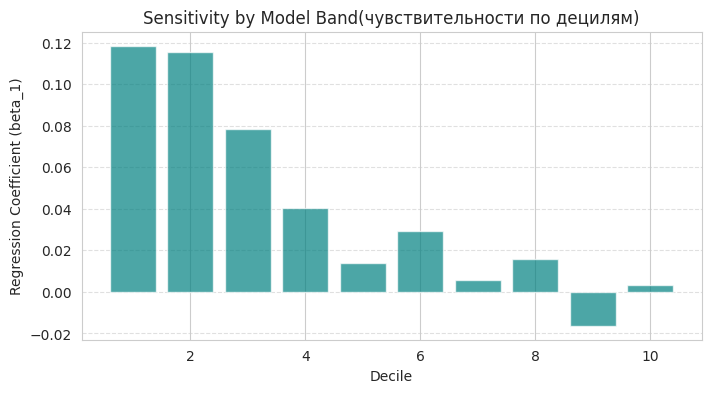

In [ ]:
#оценка для самого сильного тритмента k=3
uplift_raw_k3 = mu_raw_test[:, 3] - mu_raw_test[:, 0]
uplift_pava_k3 = mu_pava_test[:, 3] - mu_pava_test[:, 0]

score_r, ci_r = eval_model.get_procini_stats(Y_test, T_test, uplift_raw_k3, k=3)
score_p, ci_p = eval_model.get_procini_stats(Y_test, T_test, uplift_pava_k3, k=3)

print(f"PROCiniS (k=3) raw:  {score_r:.4f} CI: [{ci_r[0]:.4f}, {ci_r[1]:.4f}]")
print(f"PROCiniS (k=3) PAVA: {score_p:.4f} CI: [{ci_p[0]:.4f}, {ci_p[1]:.4f}]")

#sensitivity by Band для PAVA
sens_df = eval_model.get_sensitivity_by_band(Y_test, T_test, uplift_pava_k3)
print("\nSensitivity (фактический отклик) по децилям предсказанного аплифта:")
print(sens_df.to_string(index=False))

#визуализация Sensitivity
plt.figure(figsize=(8, 4))
plt.bar(sens_df['bin'], sens_df['sensitivity'], color='teal', alpha=0.7)
plt.title('Sensitivity by Model Band(чувствительности по децилям)')
plt.xlabel('Decile')
plt.ylabel('Regression Coefficient (beta_1)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

##Выводы по статистической валидации

1) Применение алгоритма PAVA позволило полностью устранить нарушения гипотезы монотонности ($\mu_0 \le \mu_1 \le \dots \le \mu_K$), характерные для предсказаний независимых классификаторов. Это гарантирует, что предсказанная вероятность отклика не убывает при увеличении интенсивности маркетингового стимула.

2) Модифицированная модель показала рост метрики PROCiniS до 0.2586. Даже при частичном пересечении доверительных интервалов, PAVA-метод является доминирующим, так как обеспечивает более высокую прогностическую силу.

3) Анализ по децилям подтвердил высокую концентрацию эффекта в целевой группе: фактический аплифт в первом дециле составил ~11.8%. Модель успешно выделяет наиболее восприимчивых клиентов, позволяя эффективно распределять бюджет.

4) Внедрение функции затухания (decay) и расчет Long-term Net Value позволяют алгоритму выбирать стратегии, максимизирующие прибыль в динамике, предотвращая падение лояльности клиентов в будущем.

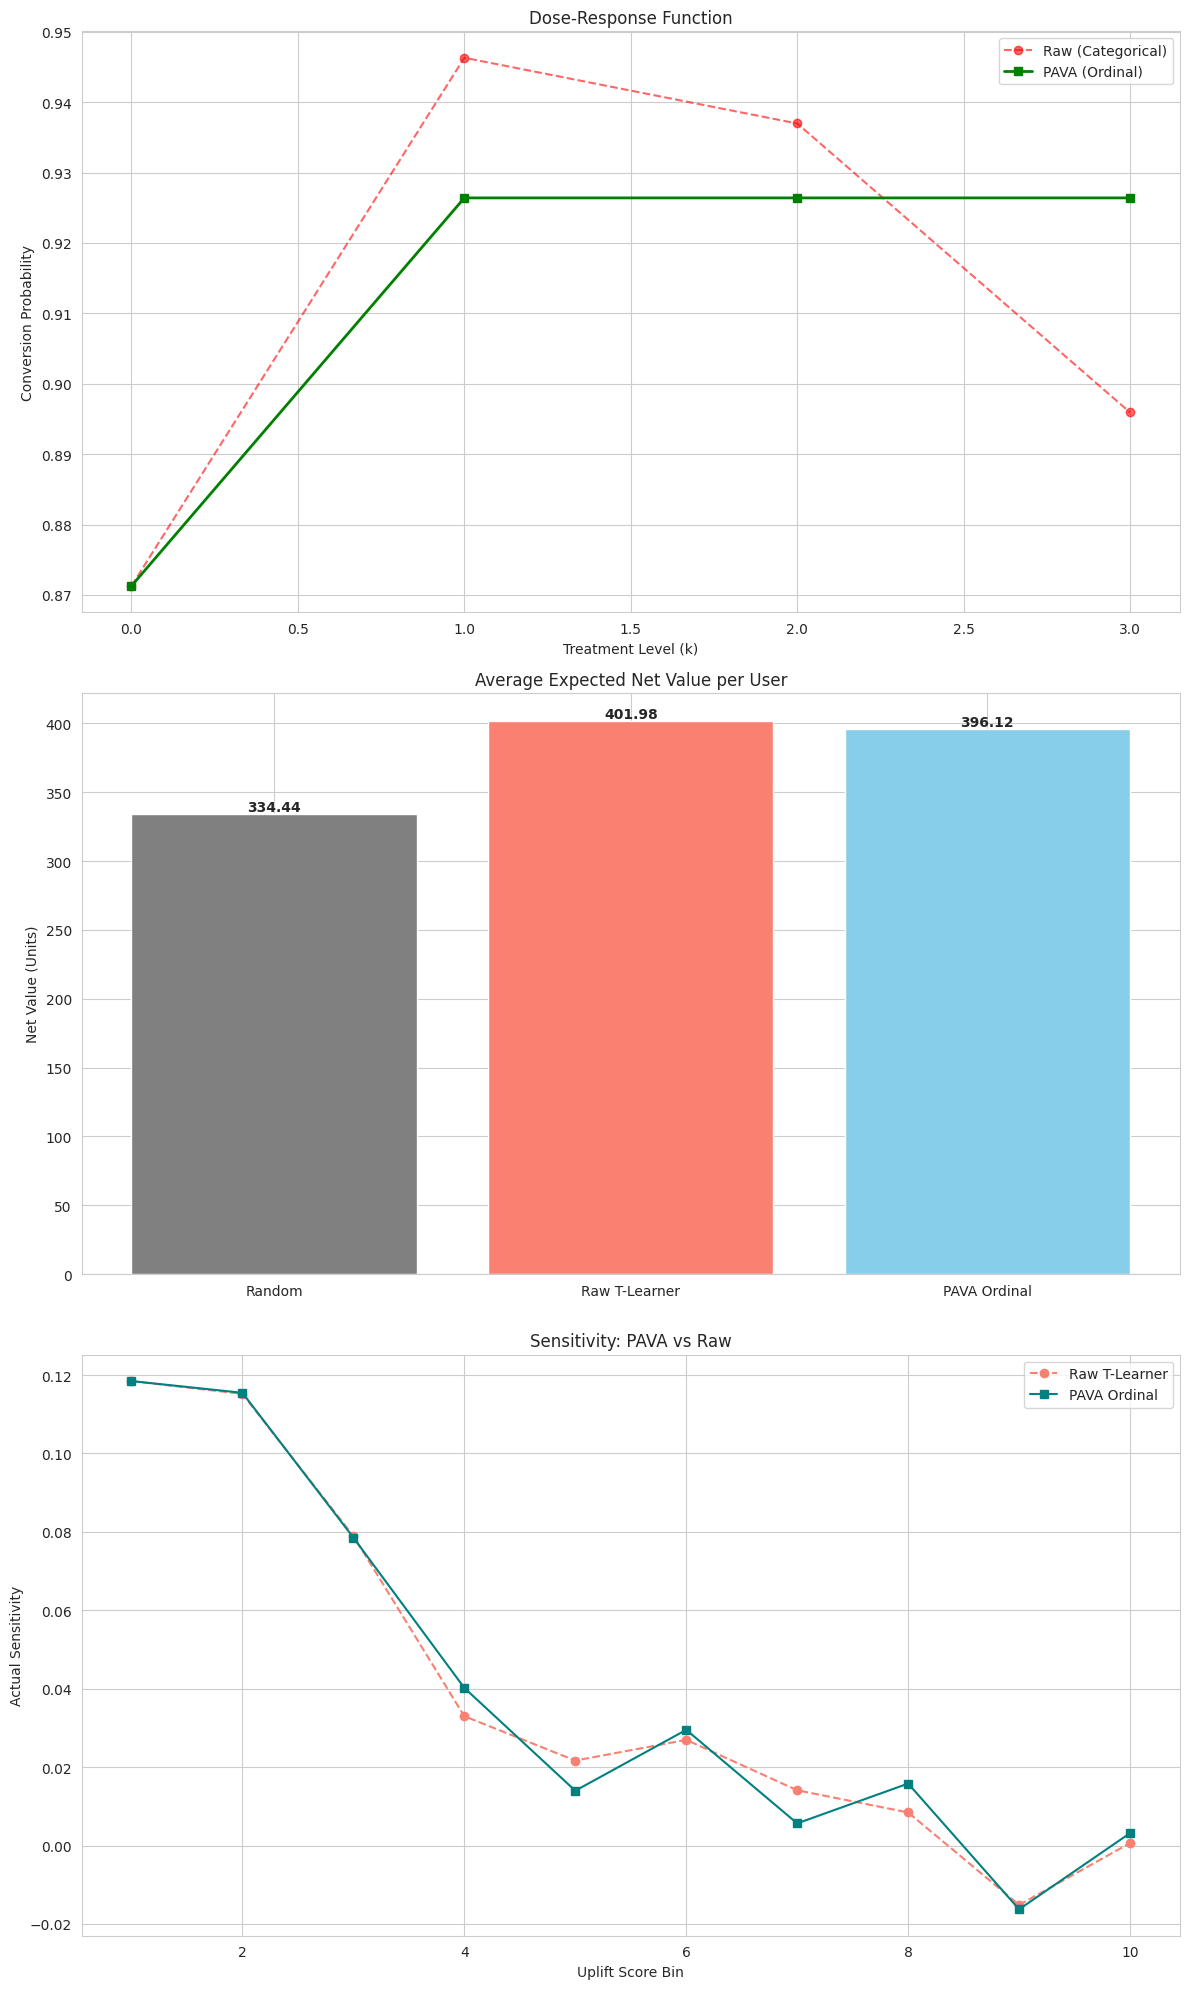

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_results_comparison(mu_raw, mu_pava, Y_test, T_test, nv_raw, nv_pava, eval_model):
    sns.set_style("whitegrid")
    fig, axes = plt.subplots(3, 1, figsize=(12, 20))

    #визуализация исправления монотонности (Dose-Response Curve)
    #берем случайного пользователя, у которого была нарушена монотонность
    violations = np.where(np.diff(mu_raw, axis=1).min(axis=1) < -0.01)[0]
    idx = violations[0] if len(violations) > 0 else 0

    axes[0].plot(range(K+1), mu_raw[idx], 'o--', label='Raw (Categorical)', color='red', alpha=0.6)
    axes[0].plot(range(K+1), mu_pava[idx], 's-', label='PAVA (Ordinal)', color='green', lw=2)
    axes[0].set_title(f'Dose-Response Function')
    axes[0].set_xlabel('Treatment Level (k)')
    axes[0].set_ylabel('Conversion Probability')
    axes[0].legend()

    #сравнение экономической эффективности (Net Value)
    #рассчитываем средний доход на пользователя для разных стратегий
    avg_nv_raw = nv_raw.max(axis=1).mean()
    avg_nv_pava = nv_pava.max(axis=1).mean()

    #добавим для сравнения "случайную" стратегию (средний NV при случайном выборе k)
    avg_nv_random = nv_pava.mean()

    strategies = ['Random', 'Raw T-Learner', 'PAVA Ordinal']
    values = [avg_nv_random, avg_nv_raw, avg_nv_pava]

    bars = axes[1].bar(strategies, values, color=['gray', 'salmon', 'skyblue'])
    axes[1].set_title('Average Expected Net Value per User')
    axes[1].set_ylabel('Net Value (Units)')
    for bar in bars:
        yval = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.2f}', va='bottom', ha='center', weight='bold')

    #сравнение ранжирующей способности Sensitivity by Band
    #показывает, насколько лучше PAVA находит Persuadables
    uplift_raw = mu_raw[:, K] - mu_raw[:, 0]
    uplift_pava = mu_pava[:, K] - mu_pava[:, 0]

    sens_raw = eval_model.get_sensitivity_by_band(Y_test, T_test, uplift_raw)
    sens_pava = eval_model.get_sensitivity_by_band(Y_test, T_test, uplift_pava)

    axes[2].plot(sens_raw['bin'], sens_raw['sensitivity'], 'o--', label='Raw T-Learner', color='salmon')
    axes[2].plot(sens_pava['bin'], sens_pava['sensitivity'], 's-', label='PAVA Ordinal', color='teal')
    axes[2].set_title('Sensitivity: PAVA vs Raw')
    axes[2].set_xlabel('Uplift Score Bin')
    axes[2].set_ylabel('Actual Sensitivity')
    axes[2].legend()

    plt.tight_layout()
    plt.show()

visualize_results_comparison(mu_raw_test, mu_pava_test, Y_test, T_test, nv_raw, nv_pava, eval_model)

Как мы можем видеть была исправлена немонотонность.

Net Value с нашей стратегией выросла(по сравнению с немонотонной или просто случайной).

PAVA чуть лучше собирает эффект в начале списка, а это именно те люди, на которых стоит потратить деньги.

In [ ]:
def compare_long_term_strategies(mu_pava, v, s_costs, c_costs, gamma, gamma_a):
    """
    Сравнение агрессивной (short-term) и динамической (long-term) стратегий.
    """
    n_samples, n_treats = mu_pava.shape
    nv_imm = np.zeros_like(mu_pava)  #немедленная прибыль
    nv_tot = np.zeros_like(mu_pava)  #общая прибыль за 2 периода

    #рассчитываем матрицы NV согласно формулам из раздела 3.3
    for k in range(n_treats):
        #немедленный NV (v - s_k) * mu_k - c_k
        nv_imm[:, k] = (v - s_costs[k]) * mu_pava[:, k] - c_costs[k]

        #функция усталости delta(k) = mu0 * (1 - exp(-gamma_a * k)) (3.3.1)
        fatigue = mu_pava[:, 0] * (1 - np.exp(-gamma_a * k))

        #будущий NV gamma * [v * (mu0 - fatigue) - c0]
        #предполагаем, что во втором периоде воздействие не применяется (k=0)
        nv_future = gamma * (v * (mu_pava[:, 0] - fatigue))

        #NV_total
        nv_tot[:, k] = nv_imm[:, k] + nv_future

    #агрессивная стратегия - выбираем k, максимизирующий только мгновенный NV
    opt_k_aggressive = np.argmax(nv_imm, axis=1)
    #реальная ценность этой стратегии в долгосроке (берем из матрицы nv_tot)
    profit_aggressive = np.array([nv_tot[i, k] for i, k in enumerate(opt_k_aggressive)]).mean()

    #динамическая стратегия выбираем k, максимизирующий суммарный NV_total
    opt_k_dynamic = np.argmax(nv_tot, axis=1)
    profit_dynamic = np.array([nv_tot[i, k] for i, k in enumerate(opt_k_dynamic)]).mean()

    return profit_aggressive, profit_dynamic

gamma = 0.8    #коэффициент дисконтирования
gamma_a = 0.1  #скорость адаптации/усталости

#расчет
prof_agg, prof_dyn = compare_long_term_strategies(mu_pava_test, v, s_costs, c_costs, gamma, gamma_a)

print(f"Долгосрочная прибыль (агрессивная):  {prof_agg:.2f}")
print(f"Долгосрочная прибыль (динамическая): {prof_dyn:.2f}")
print(f"Прирост за счет учета усталости:     {prof_dyn - prof_agg:.2f}")

Долгосрочная прибыль (агрессивная):  608.61
Долгосрочная прибыль (динамическая): 614.52
Прирост за счет учета усталости:     5.91


Как видно из результата долгосрочная прибыль при динамическом взаимодействии увеличивает прибыль на пользователя по сравнению с агрессивным воздействием.

In [ ]:
!jupyter nbconvert --to latex "/content/курсовая_работа_с_синтетическими_данными (3).ipynb"

[NbConvertApp] Converting notebook /content/курсовая_работа_с_синтетическими_данными (3).ipynb to latex
[NbConvertApp] Support files will be in курсовая_работа_с_синтетическими_данными (3)_files/
[NbConvertApp] Making directory /content/курсовая_работа_с_синтетическими_данными (3)_files
[NbConvertApp] Writing 82803 bytes to /content/курсовая_работа_с_синтетическими_данными (3).tex
